# Graded: x of 40 correct
- [10] Contains correct number of plots (1 pt each, 10 pts total)
- [10] Contains correct layout (1 pt each, 10 pts total)
- [10] Each plot contains correct data (1 pt each, 10 pts total)
- [10] Titles, labels, and axes (1 pt each, 10 pts total)

Comments: 


# Assignment 3: Constructing a visual report with Matplotlib
You are performing an analysis of fuel efficiency in personal vehicles from model years 1970 - 1980. You have extracted the following data in `list` form:
- `all_mpgs`: Fuel economy (miles per gallon) for all selected vehicle models across all years
- `all_weights`: Weights (lbs) for all selected vehicle models across all years
- `unique_model_years`: A list of model years from 1970 to 1980
- `yearly_mean_mpgs`: Average fuel economy (miles per gallon) for vehicles in each model year
- `yearly_mean_horsepower`: Average engine power (horsepower) for vehicles in each model year
- `origins_1970`: The origin for each vehicle from the 1970 model year
- `origins_1980`: The origin for each vehicle from the 1980 model year
- `origin_mean_mpgs`: Average fuel economy (miles per gallon) for vehicles from each origin
- `origin_mean_horsepower`: Average engine power (horsepower) for vehicles from each origin
- `origin_mean_cylinders`: Average number of engine cylinders for vehicles from each origin
- `origin_mean_displacement`: Average cylinder volume (cm^3) for vehicles from each origin
- `origin_mean_weight`: Average weight (lbs) for vehicles from each origin
- `origin_mean_acceleration`: Average acceleration (ft/s^2) for vehicles from each origin

Your task is to create a visual report for these data. You will create a single Matplotlib Figure containing the following subplots:
1. A scatter plot with `all_weights` on the x-axis and `all_mpgs` on the y-axis
2. A line plot with `unique_model_years` with **separate** y-axes for `yearly_mean_mpgs` and `yearly_mean_horsepower`. Include markers for each data point.
3. Two pie charts, one each for the number of models by origin in `origins_1970` and `origins_1980`
4. A series of 6 bar plots with `origin_mean_mpgs`, `origin_mean_horsepower`, `origin_mean_cylinders`, `origin_mean_displacement`, `origin_mean_weight`, and `origin_mean_acceleration` on y-axis, and each should have `unique_origins` on the x-axis.

The subplots should use a layout with 3 rows:
- Row 1, three subplots: Scatter plot (item 1 above), 2 pie charts (item 3)
- Row 2, 1 subplot stretched across the figure: Line plot (item 2)
- Row 3, 6 subplots: 6 bar plots (item 4)

Be sure to give each subplot a title and label the axes with appropriate descriptor and units. You may customize the appearance (colors, marker types, etc.) in any way you think looks appealing
<br />
<br />
The next cell loads the data and should not be changed.

In [1]:
# Do not change this cell
import pandas as pd
import seaborn as sns

data = sns.load_dataset('mpg')

all_mpgs = data['mpg'].to_list()
all_weights = data['weight'].to_list()

unique_model_years = list(data['model_year'].unique())
unique_origins = sorted(list(data['origin'].unique()))

yearly_mean_mpgs = data.groupby('model_year').mean(numeric_only=True)['mpg'].to_list()
yearly_mean_horsepower = data.groupby('model_year').mean(numeric_only=True)['horsepower'].to_list()

origins_1970 = data.loc[data['model_year'] == 70, 'origin']
origins_1980 = data.loc[data['model_year'] == 80, 'origin']

origin_mean_mpgs = data.groupby('origin').mean(numeric_only=True)['mpg'].to_list()
origin_mean_horsepower = data.groupby('origin').mean(numeric_only=True)['horsepower'].to_list()
origin_mean_cylinders = data.groupby('origin').mean(numeric_only=True)['cylinders'].to_list()
origin_mean_displacement = data.groupby('origin').mean(numeric_only=True)['displacement'].to_list()
origin_mean_weight = data.groupby('origin').mean(numeric_only=True)['weight'].to_list()
origin_mean_acceleration = data.groupby('origin').mean(numeric_only=True)['acceleration'].to_list()


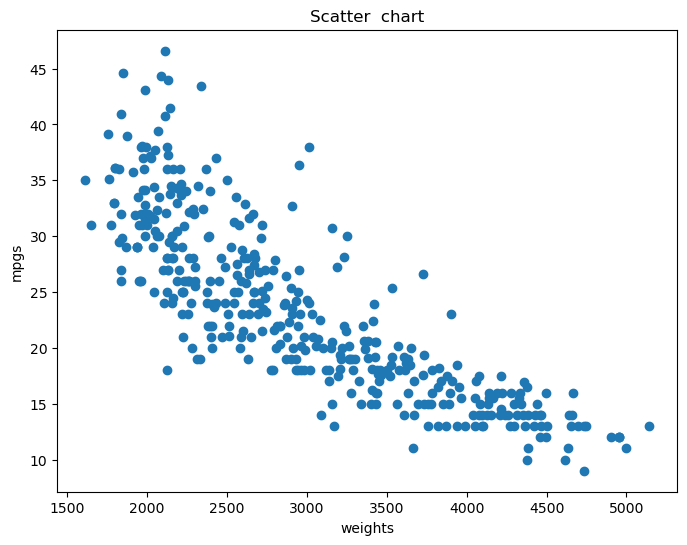

In [2]:
# A scatter plot with `all_weights` on the x-axis and `all_mpgs` on the y-axis

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(all_weights,all_mpgs)
plt.xlabel("weights")
plt.ylabel("mpgs")
plt.title("Scatter  chart")
plt.show()

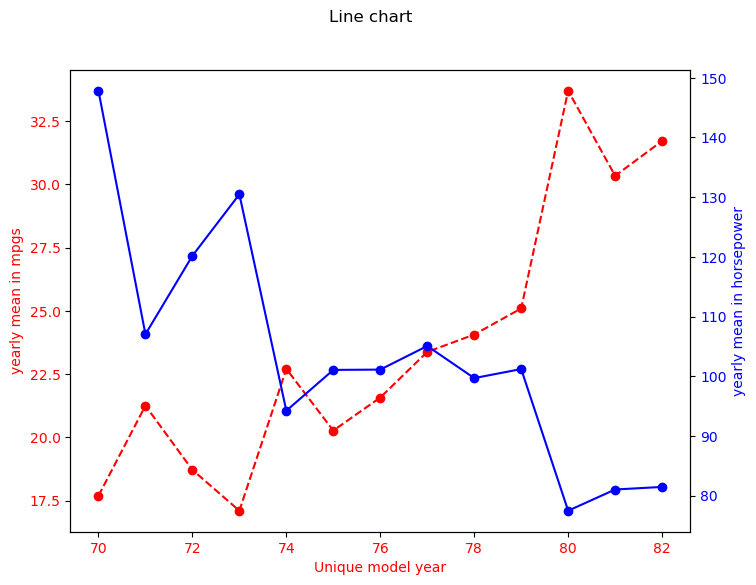

In [3]:
# A line plot with `unique_model_years` with **separate** y-axes for `yearly_mean_mpgs` and `yearly_mean_horsepower`. Include markers for each data point.

fig,axe = plt.subplots(figsize=(8,6))
fig.suptitle("Line chart")
axe.plot(unique_model_years, yearly_mean_mpgs, marker="o",color="red",linestyle="--")
axe.set_xlabel("Unique model year",color="red")
axe.set_ylabel("yearly mean in mpgs", color="red")
axe.tick_params(labelcolor="red")

axe2=axe.twinx()
axe2.plot(unique_model_years, yearly_mean_horsepower, marker="o",color="blue")
axe2.set_xlabel("Unique model year",color="blue")
axe2.set_ylabel("yearly mean in horsepower", color="blue")
axe2.tick_params(labelcolor="blue")

plt.show()


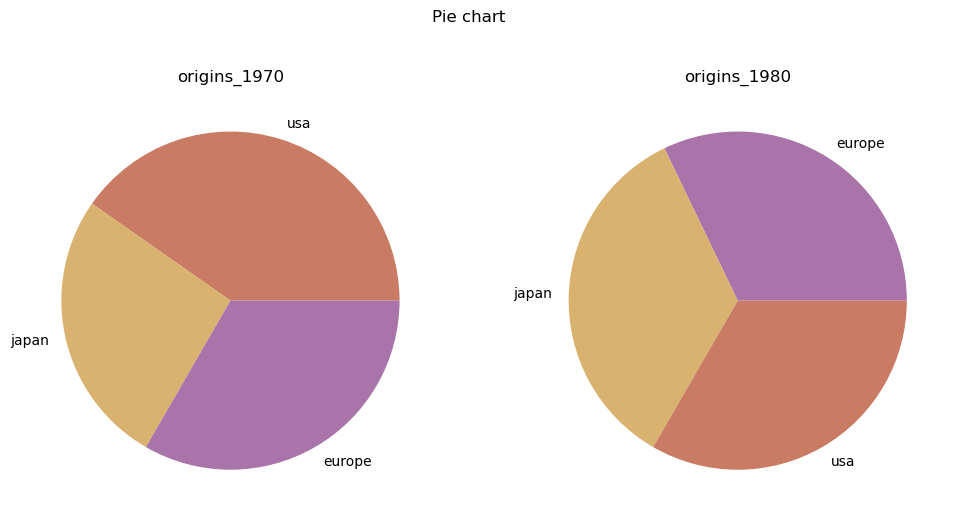

In [4]:
# Two pie charts, one each for the number of models by origin in `origins_1970` and `origins_1980`

from matplotlib.gridspec import GridSpec

origins_1970 = data.loc[data['model_year'] == 70, 'origin']
origins_1980 = data.loc[data['model_year'] == 80, 'origin']

#print(origins_1970)

color_map={}
for origin in unique_origins:
    if origin=="usa":
        color_map[origin] = "#C97B63"
    elif origin == "japan":
        color_map[origin]="#D9B26F"
    else:
        color_map[origin]="#A974A9"

fig = plt.figure(figsize=(12,6))
fig.suptitle("Pie chart")
gs = GridSpec(1,2,figure = fig)
axe1 = fig.add_subplot(gs[0,0])
pie_origin70={}

for i,origin in enumerate(origins_1970):
    pie_origin70[origin]=i
    if origin in pie_origin70:
        pie_origin70[origin]+=1

slices = list(pie_origin70.values())
titles = list(pie_origin70.keys())

colors1=[color_map[title] for title in titles]

axe1.pie(slices,labels=titles,colors=colors1)
axe1.set_title("origins_1970")



axe2 = fig.add_subplot(gs[0,1])
pie_origin80={}
for i,origin in enumerate(origins_1980):
    pie_origin80[origin]=i
    if origin in pie_origin80:
        pie_origin80[origin]+=1

slices = list(pie_origin80.values())
titles = list(pie_origin80.keys())
colors2=[color_map[title] for title in titles]

axe2.pie(slices,labels=titles,colors=colors2)

axe2.set_title("origins_1980")

plt.show()



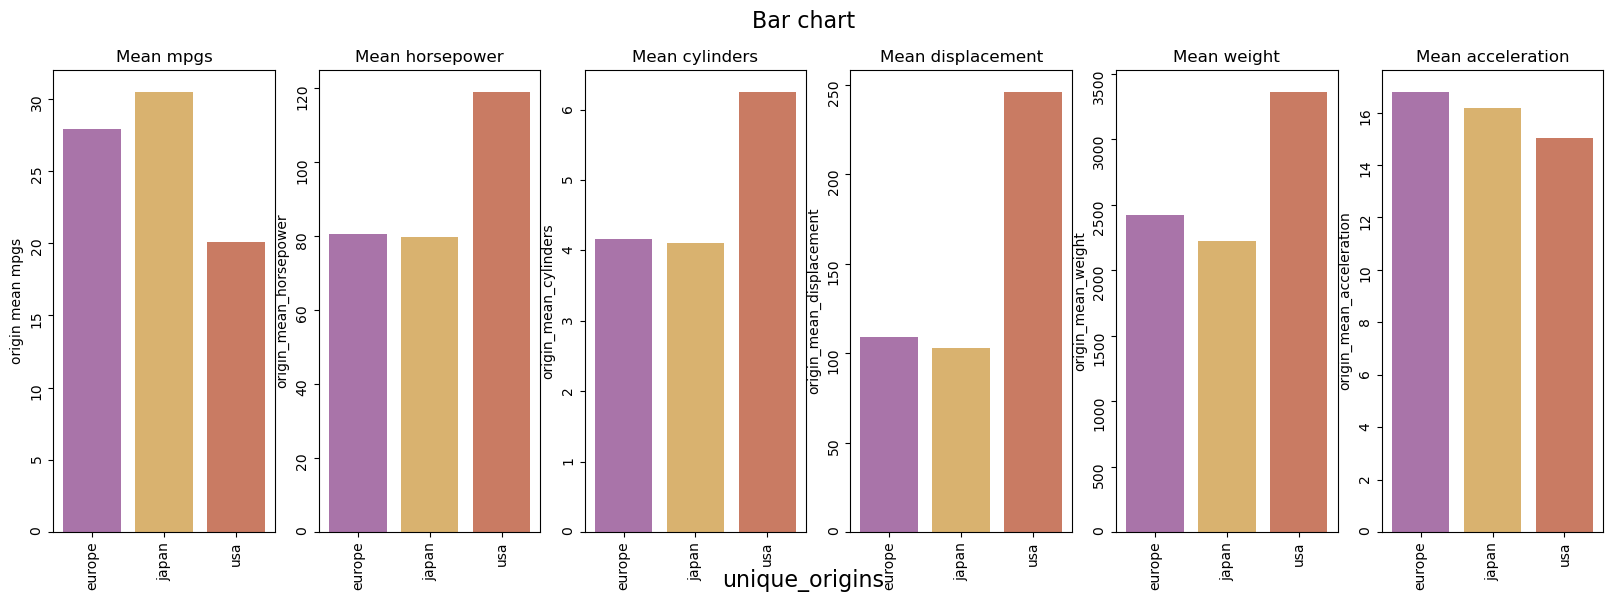

In [5]:
# A series of 6 bar plots with `origin_mean_mpgs`, `origin_mean_horsepower`, `origin_mean_cylinders`, `origin_mean_displacement`, `origin_mean_weight`, and `origin_mean_acceleration` on y-axis, and each should have `unique_origins` on the x-axis.
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(20,6))

gs = GridSpec(1,6,figure=fig)

color=[]
for origin in unique_origins:
    if origin=="usa":
        color.append("#C97B63")
    elif origin == "japan":
        color.append("#D9B26F")
    else:
        color.append("#A974A9")



axe1 = fig.add_subplot(gs[0,0])
axe1.bar(unique_origins,origin_mean_mpgs,color=color)
axe1.set_ylabel("origin mean mpgs")
axe1.set_title("Mean mpgs")
axe1.tick_params(rotation=90)



axe2 = fig.add_subplot(gs[0,1])
axe2.bar(unique_origins,origin_mean_horsepower,color=color)
axe2.set_ylabel("origin_mean_horsepower")
axe2.set_title("Mean horsepower")
axe2.tick_params(rotation=90)

axe3 = fig.add_subplot(gs[0,2])
axe3.bar(unique_origins,origin_mean_cylinders,color=color)
axe3.set_ylabel("origin_mean_cylinders")
axe3.set_title("Mean cylinders")
axe3.tick_params(rotation=90)

axe4 = fig.add_subplot(gs[0,3])
axe4.bar(unique_origins,origin_mean_displacement,color=color)
axe4.set_ylabel("origin_mean_displacement")
axe4.set_title("Mean displacement")
axe4.tick_params(rotation=90)

axe5 = fig.add_subplot(gs[0,4])
axe5.bar(unique_origins,origin_mean_weight,color=color)
axe5.set_ylabel("origin_mean_weight")
axe5.set_title("Mean weight")
axe5.tick_params(rotation=90)

axe6 = fig.add_subplot(gs[0,5])
axe6.bar(unique_origins,origin_mean_acceleration,color=color)
axe6.set_ylabel("origin_mean_acceleration")
axe6.set_title("Mean acceleration")
axe6.tick_params(rotation=90)

fig.supxlabel("unique_origins",fontsize=16)
fig.suptitle("Bar chart",fontsize=16)

plt.show()



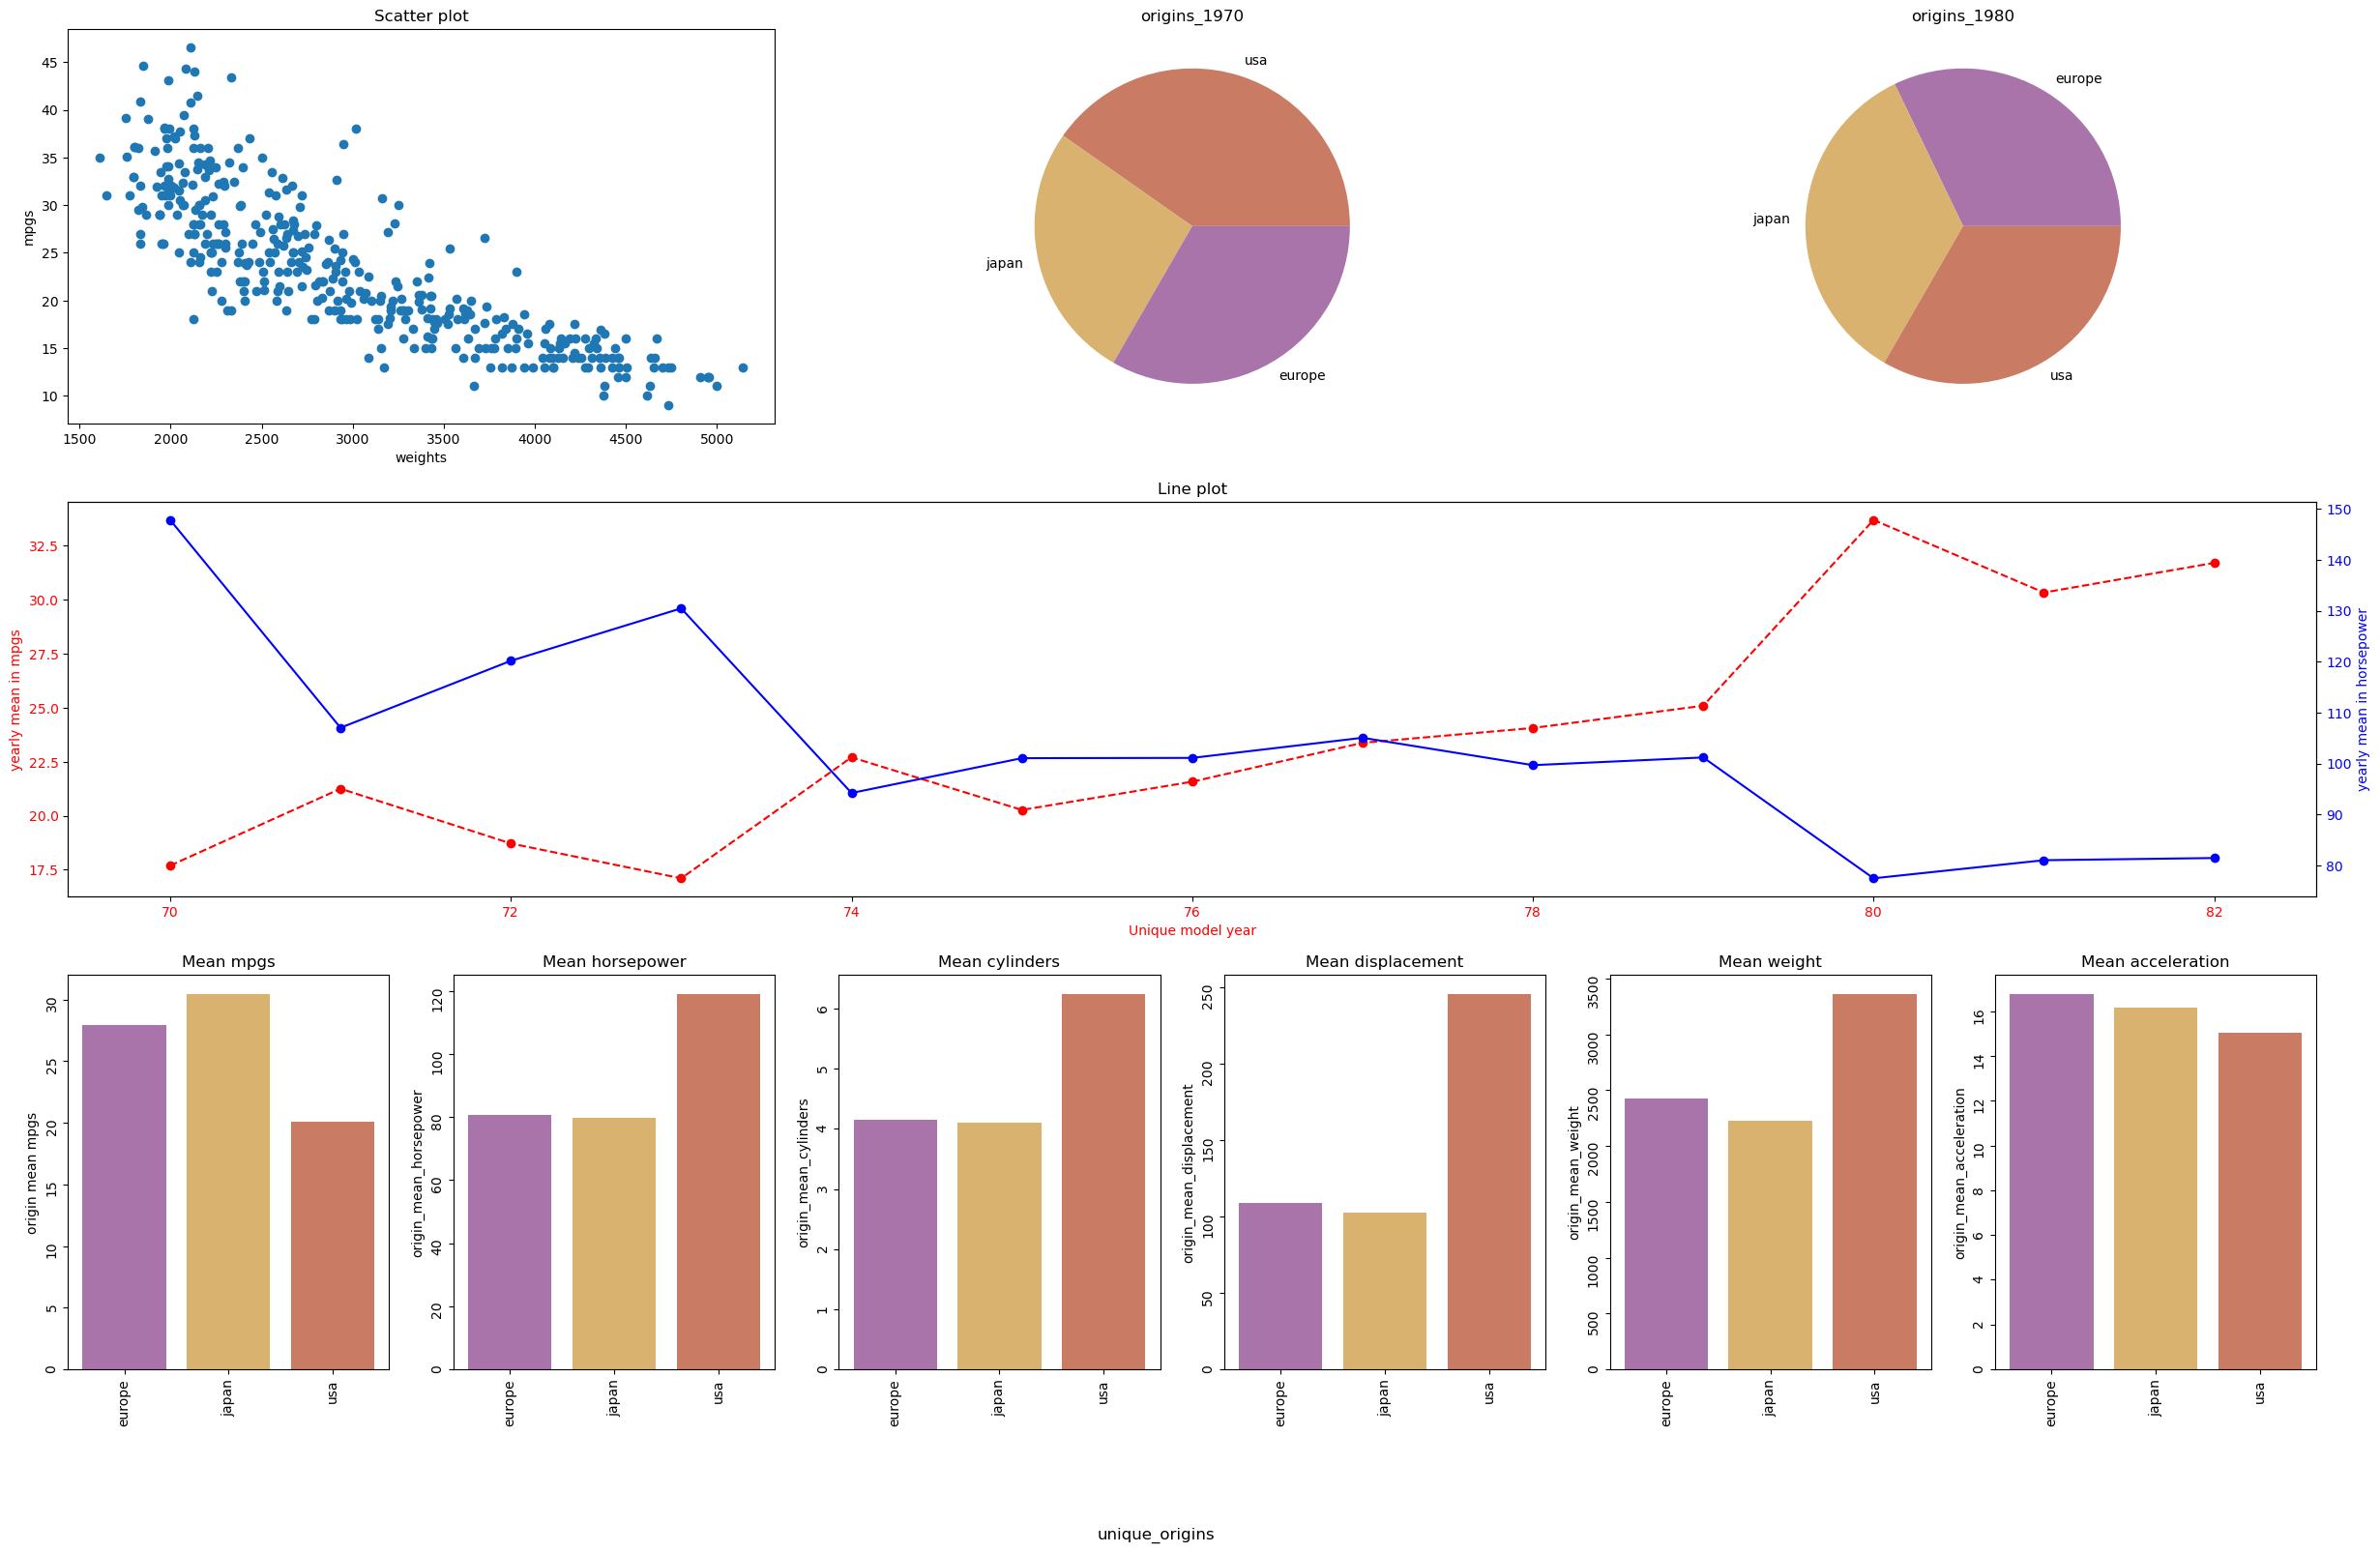

In [6]:
# The subplots should use a layout with 3 rows:
#- Row 1, three subplots: Scatter plot (item 1 above), 2 pie charts (item 3)
#- Row 2, 1 subplot stretched across the figure: Line plot (item 2)
#- Row 3, 6 subplots: 6 bar plots (item 4)

#Be sure to give each subplot a title and label the axes with appropriate descriptor and units. You may customize the appearance (colors, marker types, etc.) in any way you think looks appealing




fig = plt.figure(figsize=(30,18))
gs = GridSpec(3,6,figure=fig)

#Row 1 

axe1 = plt.subplot(gs[0,:2])
axe1.scatter(all_weights,all_mpgs)
axe1.set_xlabel("weights")
axe1.set_ylabel("mpgs")
axe1.set_title("Scatter plot")


color_map={}
for origin in unique_origins:
    if origin=="usa":
        color_map[origin] = "#C97B63"
    elif origin == "japan":
        color_map[origin]="#D9B26F"
    else:
        color_map[origin]="#A974A9"


axe2 = fig.add_subplot(gs[0,2:4])
pie_origin70={}

for i,origin in enumerate(origins_1970):
    pie_origin70[origin]=i
    if origin in pie_origin70:
        pie_origin70[origin]+=1

slices = list(pie_origin70.values())
titles = list(pie_origin70.keys())
colors1=[color_map[title] for title in titles]
axe2.pie(slices,labels=titles,colors=colors1)
axe2.set_title("origins_1970")


axe3 = fig.add_subplot(gs[0,4:])
pie_origin80={}
for i,origin in enumerate(origins_1980):
    pie_origin80[origin]=i
    if origin in pie_origin80:
        pie_origin80[origin]+=1

slices = list(pie_origin80.values())
titles = list(pie_origin80.keys())
colors2=[color_map[title] for title in titles]
axe3.pie(slices,labels=titles,colors=colors2)
axe3.set_title("origins_1980")


#row2

axe4 = plt.subplot(gs[1,:])
axe4.plot(unique_model_years, yearly_mean_mpgs, marker="o",color="red",linestyle="--")
axe4.set_xlabel("Unique model year",color="red")
axe4.set_ylabel("yearly mean in mpgs", color="red")
axe4.tick_params(labelcolor="red")
axe4.set_title("Line plot")

axe5=axe4.twinx()
axe5.plot(unique_model_years, yearly_mean_horsepower, marker="o",color="blue")
axe5.set_xlabel("Unique model year",color="blue")
axe5.set_ylabel("yearly mean in horsepower", color="blue")
axe5.tick_params(labelcolor="blue")

#Row 3

color=[]
for origin in unique_origins:
    if origin=="usa":
        color.append("#C97B63")
    elif origin == "japan":
        color.append("#D9B26F")
    else:
        color.append("#A974A9")

axe6 = fig.add_subplot(gs[2,0])
axe6.bar(unique_origins,origin_mean_mpgs,color=color)
axe6.set_ylabel("origin mean mpgs")
axe6.set_title("Mean mpgs")
axe6.tick_params(rotation=90)

axe7 = fig.add_subplot(gs[2,1])
axe7.bar(unique_origins,origin_mean_horsepower,color=color)
axe7.set_ylabel("origin_mean_horsepower")
axe7.set_title("Mean horsepower")
axe7.tick_params(rotation=90)

axe8 = fig.add_subplot(gs[2,2])
axe8.bar(unique_origins,origin_mean_cylinders,color=color)
axe8.set_ylabel("origin_mean_cylinders")
axe8.set_title("Mean cylinders")
axe8.tick_params(rotation=90)

axe9 = fig.add_subplot(gs[2,3])
axe9.bar(unique_origins,origin_mean_displacement,color=color)
axe9.set_ylabel("origin_mean_displacement")
axe9.set_title("Mean displacement")
axe9.tick_params(rotation=90)

axe10 = fig.add_subplot(gs[2,4])
axe10.bar(unique_origins,origin_mean_weight,color=color)
axe10.set_ylabel("origin_mean_weight")
axe10.set_title("Mean weight")
axe10.tick_params(rotation=90)

axe11= fig.add_subplot(gs[2,5])
axe11.bar(unique_origins,origin_mean_acceleration,color=color)
axe11.set_ylabel("origin_mean_acceleration")
axe11.set_title("Mean acceleration")
axe11.tick_params(rotation=90)

fig.supxlabel("unique_origins")


plt.show()